In [ ]:
import os
import logging

# import keras.backend as k  # Removed Keras backend
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests
# import tensorflow as tf  # Removed as we're using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# from gradientAttack import GradientAttack, ProjectedGradientDescent, FastGradientMethod
# from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from io import BytesIO
from IPython.display import clear_output
# from keras import optimizers  # Removed Keras optimizers
# from keras.datasets import mnist  # Will use torchvision.datasets instead
# from keras.layers import Activation, Conv2D, Dense, Flatten, MaxPooling2D  # Removed Keras layers
# from keras.models import load_model, Model, Sequential  # Removed Keras models
# from keras.utils import to_categorical  # Will use torch.nn.functional.one_hot instead
from PIL import Image
from sklearn.metrics import confusion_matrix
# from tensorflow.python.ops.parallel_for.gradients import batch_jacobian  # Will use torch.autograd instead
# from tqdm.keras import TqdmCallback  # Removed Keras callback
from tqdm.notebook import tqdm

# Remove tensorflow warning suppression as it's no longer needed
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# logging.getLogger('tensorflow').setLevel(logging.FATAL)


#suppress tensorflow warnings
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# logging.getLogger('tensorflow').setLevel(logging.FATAL)

In [34]:
from tqdm import tqdm

In [6]:
url = 'http://127.0.0.1:9000/predict'

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

100%|██████████| 9.91M/9.91M [00:11<00:00, 852kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 309kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.19MB/s]


In [15]:
def display_sample(sample):
    """
    Display a sample from the MNIST dataset
    :param sample: PyTorch tensor or tuple of (tensor, label)
    """
    # Handle both single tensor and (tensor, label) tuple inputs
    if isinstance(sample, tuple):
        image, label = sample
    else:
        image = sample
        label = None
    
    # Convert PyTorch tensor to numpy and denormalize
    image_array = ((image.squeeze() * 0.3081) + 0.1307) * 255
    image_array = image_array.numpy().astype(np.uint8)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image_array, cmap='gray')
    if label is not None:
        plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

Oracle prediction: 0
True label: 0


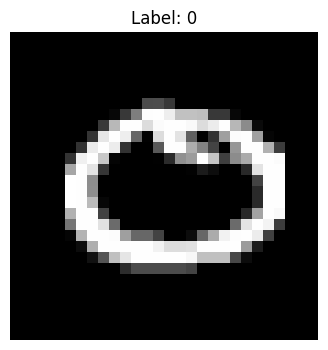

In [20]:
def query_oracle(sample):
    """
    Send a single classification query to the oracle
    :param sample: PyTorch tensor or tuple of (tensor, label)
    :return: predicted class as integer
    """
    # Handle both single tensor and (tensor, label) tuple inputs
    if isinstance(sample, tuple):
        sample = sample[0]  # Get just the image tensor
    
    # Convert PyTorch tensor to numpy array and prepare for PIL
    # Denormalize and convert to uint8 format
    image_array = ((sample.squeeze() * 0.3081) + 0.1307) * 255
    image_array = image_array.numpy().astype(np.uint8)
    
    buffer = BytesIO()
    image = Image.fromarray(image_array)
    image.save(buffer, format='PNG')
    files = {'file': ('image.png', buffer.getvalue(), 'image/png')}
    response = requests.post(url, files=files)
    return int(response.json()['prediction'])

# Example usage:
sample = train_dataset[np.random.randint(len(train_dataset))]
print(f"Oracle prediction: {query_oracle(sample)}")
print(f"True label: {sample[1]}")
display_sample(sample)

In [37]:
def get_oracle_predictions(dataset):
    """
    Call oracle function on a PyTorch dataset
    :param dataset: PyTorch dataset
    :return: predicted class as numpy array (int) with shape (-1)
    """
      # Use standard tqdm instead of notebook version
    
    preds = []
    for i in tqdm(range(len(dataset)), desc="Getting predictions"):
        preds.append(query_oracle(dataset[i]))
    return np.array(preds)

In [38]:
test_subset = torch.utils.data.Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

In [39]:
pred = get_oracle_predictions(test_subset)

Getting predictions: 100%|██████████| 1000/1000 [00:02<00:00, 436.86it/s]


In [43]:
pred

array([7, 8, 3, 6, 2, 2, 6, 3, 2, 1, 0, 2, 6, 3, 7, 1, 4, 6, 4, 5, 2, 5,
       4, 7, 3, 3, 6, 3, 3, 4, 6, 8, 1, 4, 5, 2, 7, 1, 7, 9, 2, 4, 6, 4,
       2, 6, 0, 6, 3, 3, 1, 7, 2, 6, 3, 3, 7, 5, 4, 0, 5, 3, 8, 3, 4, 9,
       2, 2, 5, 6, 6, 4, 2, 6, 9, 1, 2, 4, 2, 6, 9, 0, 5, 3, 2, 9, 8, 5,
       2, 3, 0, 0, 3, 3, 7, 3, 6, 3, 5, 0, 7, 2, 3, 1, 5, 8, 4, 9, 6, 2,
       0, 5, 5, 7, 8, 0, 6, 0, 3, 7, 8, 4, 1, 3, 0, 3, 7, 2, 5, 9, 1, 6,
       5, 3, 5, 5, 4, 7, 5, 6, 0, 7, 5, 9, 2, 4, 1, 6, 6, 8, 2, 3, 2, 0,
       5, 5, 7, 9, 1, 3, 0, 0, 6, 0, 2, 9, 5, 2, 9, 4, 2, 6, 8, 9, 9, 6,
       5, 4, 4, 1, 1, 1, 1, 2, 3, 8, 3, 3, 8, 4, 1, 4, 8, 8, 5, 0, 6, 3,
       5, 2, 8, 3, 0, 3, 6, 0, 1, 5, 6, 7, 5, 9, 3, 3, 0, 7, 0, 7, 8, 6,
       5, 9, 4, 3, 4, 6, 8, 9, 9, 1, 6, 1, 1, 1, 8, 6, 9, 4, 2, 2, 6, 4,
       3, 9, 0, 1, 9, 4, 4, 1, 3, 1, 6, 0, 6, 3, 1, 9, 6, 4, 0, 7, 9, 8,
       4, 0, 3, 5, 7, 9, 0, 0, 9, 2, 6, 2, 9, 9, 2, 1, 4, 4, 5, 7, 1, 1,
       2, 9, 8, 8, 7, 1, 9, 0, 9, 9, 9, 5, 4, 7, 5,

In [44]:
def get_accuracy(pred, labels):
    """
    Calculate accuracy
    :param pred: predicted class as numpy array (int) with shape (-1)
    :param labels: true class as numpy array (int) with shape (-1)
    :return: accuracy as float
    """
    if torch.is_tensor(labels):
        labels = labels.numpy()
    return np.mean(pred == labels)


In [45]:
print(f"Accuracy: {get_accuracy(pred, test_subset.dataset.targets[test_subset.indices])}")

Accuracy: 0.994


In [54]:
def plot_confusion_matrix(pred, labels, title="Confusion matrix"):
    """
    Plot confusion matrix
    :param pred: predicted class as numpy array (int) with shape (-1)
    :param labels: true class as numpy array (int) with shape (-1)
    :param title: title of the plot
    """
    if torch.is_tensor(labels):
        labels = labels.numpy()
        
    conf_mat = confusion_matrix(labels, pred)
    # Normalize per ground truth label, display as percentage
    conf_mat_norm = conf_mat / conf_mat.astype(np.float64).sum(axis=1, keepdims=True) * 100

    fig = plt.figure(figsize=(16, 6))
    gs = gridspec.GridSpec(1, 2)
    plt.tight_layout()
    fig.suptitle(title, fontsize = 16)

    ax0 = plt.subplot(gs[0,0])
    ax0.set_title(f'Counting {pred.shape[0]} samples')
    sns.heatmap(conf_mat, annot=True, fmt="d",cmap="Blues", ax=ax0, annot_kws={"fontsize":8})
    ax0.set_ylabel('True label')
    ax0.set_xlabel('Predicted label')

    ax1 = plt.subplot(gs[0,1])
    ax1.set_title('Prediction percentage per true class')
    sns.heatmap(conf_mat_norm, annot=True, fmt=".3g", cmap="Blues", ax=ax1, annot_kws={"fontsize":8})
    ax1.set_ylabel('True label')
    ax1.set_xlabel('Predicted label')
    return  

In [56]:
# Code: Evaluate the oracle on MNIST (test) and plot its confusion matrix.
print(f"Querying the oracle on {len(test_dataset)} images.")
y_hat_test = get_oracle_predictions(test_dataset)


Querying the oracle on 10000 images.


Getting predictions: 100%|██████████| 10000/10000 [00:21<00:00, 458.27it/s]


Oracle accuracy on MNIST test set: 0.9896


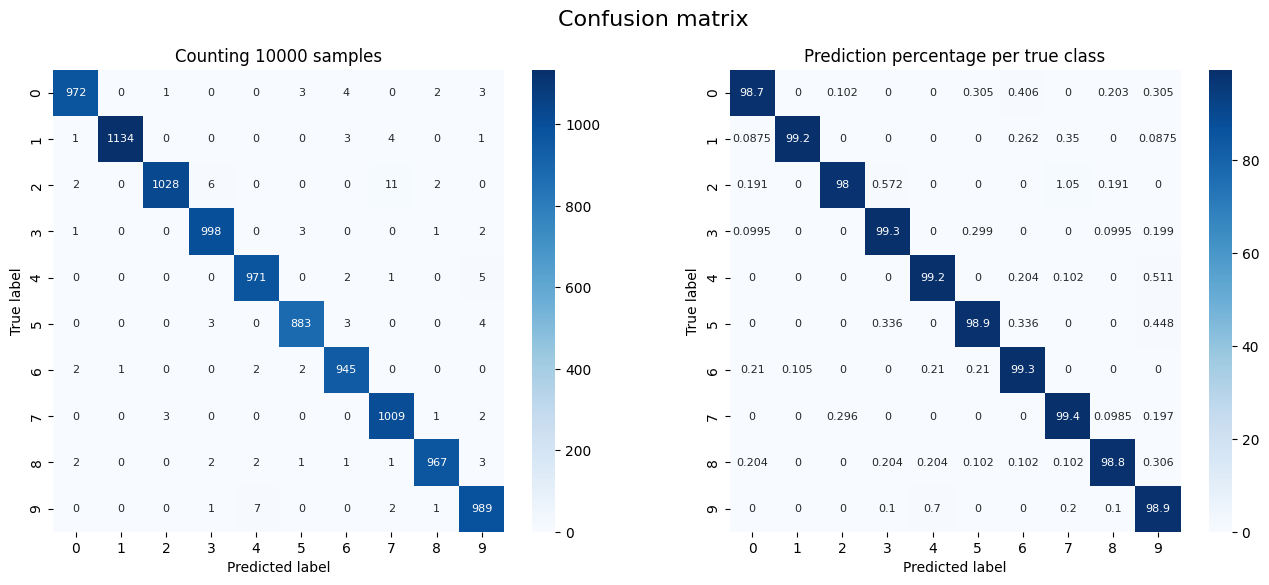

In [55]:
print(f"Oracle accuracy on MNIST test set: {get_accuracy( y_hat_test,test_dataset.targets)}")
plot_confusion_matrix(test_dataset.targets, y_hat_test);